In [ ]:
!pip install pandas numpy matplotlib seaborn nltk spacy scikit-learn

In [ ]:
import pandas as pd
import random
from datetime import datetime, timedelta

# Generate synthetic chatbot interaction data
num_samples = 1000

# Sample user queries and chatbot responses
user_queries = [
    "What are your working hours?", "How do I reset my password?", "Tell me a joke.",
    "Can you help me book an appointment?", "What's the weather like today?",
    "I want to cancel my order.", "Where is my refund?", "Thank you!", "Hello!", "Who are you?"
]

chatbot_responses = [
    "Our working hours are 9 AM to 6 PM.", "You can reset your password by clicking on 'Forgot Password'.",
    "Why don’t scientists trust atoms? Because they make up everything!",
    "Sure! Please provide the date and time.", "I’m sorry, but I don’t have access to weather data.",
    "I can help with that. What is your order ID?", "Refunds typically take 5-7 business days.",
    "You're welcome!", "Hello! How can I assist you?", "I am a virtual assistant."
]

intents = ["General Inquiry", "Account Support", "Entertainment", "Appointment Booking", "Weather",
           "Order Management", "Refunds", "Gratitude", "Greeting", "Introduction"]

sentiments = ["Positive", "Neutral", "Negative"]

# Generate timestamps
start_time = datetime(2025, 3, 1, 9, 0, 0)  # Start date
timestamps = [start_time + timedelta(minutes=random.randint(1, 5000)) for _ in range(num_samples)]

# Generate dataset
data = {
    "Timestamp": timestamps,
    "User Query": [random.choice(user_queries) for _ in range(num_samples)],
    "Chatbot Response": [random.choice(chatbot_responses) for _ in range(num_samples)],
    "Sentiment": [random.choice(sentiments) for _ in range(num_samples)],
    "Response Time (seconds)": [round(random.uniform(0.5, 5.0), 2) for _ in range(num_samples)],
    "Intent": [random.choice(intents) for _ in range(num_samples)]
}

# Create DataFrame
df = pd.DataFrame(data)

# Save to CSV
file_path = "/content/chatbot_interactions.csv"
df.to_csv(file_path, index=False)

file_path


'/content/chatbot_interactions.csv'

In [ ]:
import pandas as pd

df = pd.read_csv("chatbot_interactions.csv")
df.head()  # View first few rows


,Timestamp,User Query,Chatbot Response,Sentiment,Response Time (seconds),Intent
0,2025-03-04 08:29:00,How do I reset my password?,I am a virtual assistant.,Positive,2.09,Refunds
1,2025-03-03 10:55:00,I want to cancel my order.,Why don’t scientists trust atoms? Because they...,Positive,2.39,Order Management
2,2025-03-02 02:55:00,Who are you?,You can reset your password by clicking on 'Fo...,Neutral,3.06,Gratitude
3,2025-03-04 17:14:00,Who are you?,Refunds typically take 5-7 business days.,Negative,3.02,Gratitude
4,2025-03-02 16:53:00,How do I reset my password?,I can help with that. What is your order ID?,Neutral,3.88,Introduction


In [ ]:
# Check for missing values
print(df.isnull().sum())

# Check for duplicate rows
print("Duplicates:", df.duplicated().sum())

# Drop duplicates if needed
df = df.drop_duplicates()


Timestamp                  0
User Query                 0
Chatbot Response           0
Sentiment                  0
Response Time (seconds)    0
Intent                     0
dtype: int64
Duplicates: 0


In [ ]:
# Convert Timestamp column
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# Extract useful time features
df['Hour'] = df['Timestamp'].dt.hour
df['Day'] = df['Timestamp'].dt.day
df['Month'] = df['Timestamp'].dt.month

df.head()


,Timestamp,User Query,Chatbot Response,Sentiment,Response Time (seconds),Intent,Hour,Day,Month
0,2025-03-04 08:29:00,How do I reset my password?,I am a virtual assistant.,Positive,2.09,Refunds,8,4,3
1,2025-03-03 10:55:00,I want to cancel my order.,Why don’t scientists trust atoms? Because they...,Positive,2.39,Order Management,10,3,3
2,2025-03-02 02:55:00,Who are you?,You can reset your password by clicking on 'Fo...,Neutral,3.06,Gratitude,2,2,3
3,2025-03-04 17:14:00,Who are you?,Refunds typically take 5-7 business days.,Negative,3.02,Gratitude,17,4,3
4,2025-03-02 16:53:00,How do I reset my password?,I can help with that. What is your order ID?,Neutral,3.88,Introduction,16,2,3


In [ ]:
# Clean text data
df['User Query'] = df['User Query'].str.lower().str.strip()
df['Chatbot Response'] = df['Chatbot Response'].str.lower().str.strip()

In [ ]:
df.head()

,Timestamp,User Query,Chatbot Response,Sentiment,Response Time (seconds),Intent,Hour,Day,Month
0,2025-03-04 08:29:00,how do i reset my password?,i am a virtual assistant.,Positive,2.09,Refunds,8,4,3
1,2025-03-03 10:55:00,i want to cancel my order.,why don’t scientists trust atoms? because they...,Positive,2.39,Order Management,10,3,3
2,2025-03-02 02:55:00,who are you?,you can reset your password by clicking on 'fo...,Neutral,3.06,Gratitude,2,2,3
3,2025-03-04 17:14:00,who are you?,refunds typically take 5-7 business days.,Negative,3.02,Gratitude,17,4,3
4,2025-03-02 16:53:00,how do i reset my password?,i can help with that. what is your order id?,Neutral,3.88,Introduction,16,2,3


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")

<ipython-input-10-bbc9cf2a56a3>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df["Sentiment"], palette="coolwarm")


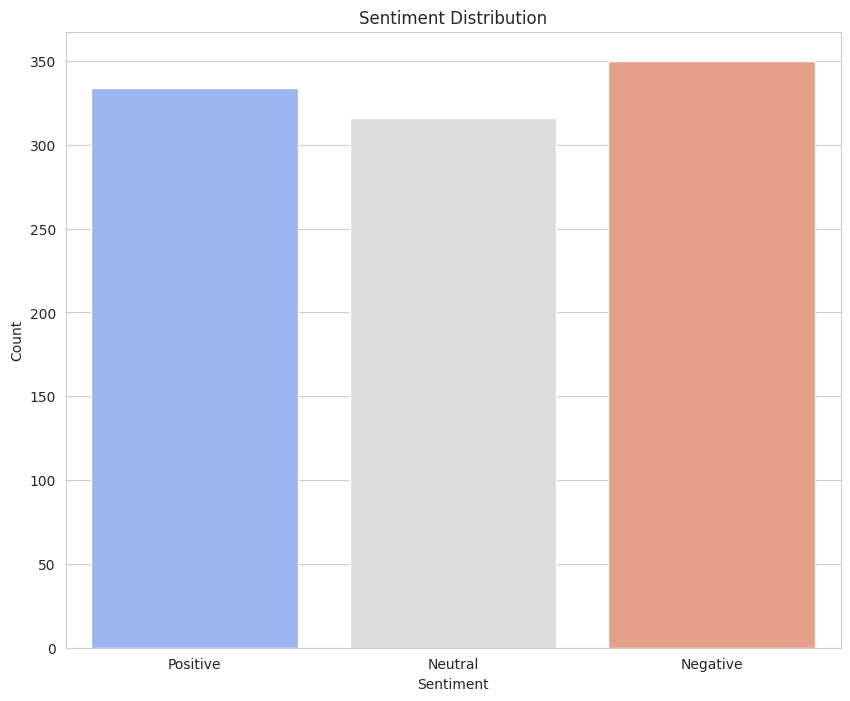

In [ ]:
# Sentiment distribution
plt.figure(figsize=(10,8))
sns.countplot(x=df["Sentiment"], palette="coolwarm")
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

<ipython-input-14-b0c7a721c1c6>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df["Intent"], order=df["Intent"].value_counts().index, palette="viridis")


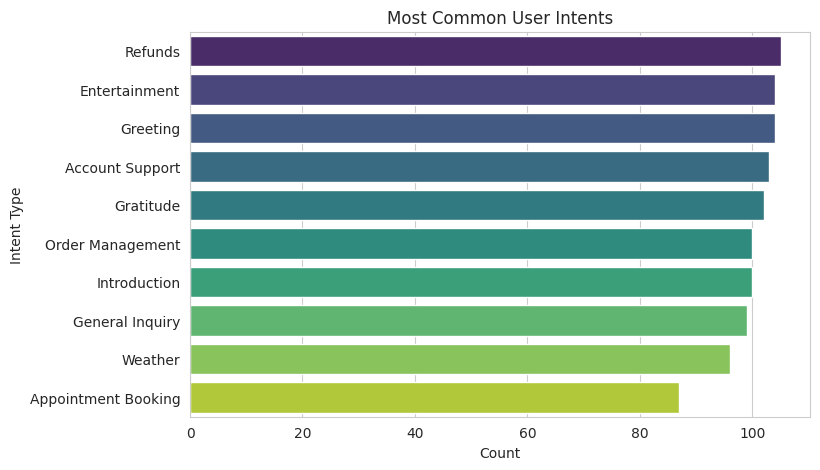

In [ ]:
# Intent distribution :-types of queries are the most frequent
plt.figure(figsize=(8,5))
sns.countplot(y=df["Intent"], order=df["Intent"].value_counts().index, palette="viridis")
plt.title("Most Common User Intents")
plt.xlabel("Count")
plt.ylabel("Intent Type")
plt.show()

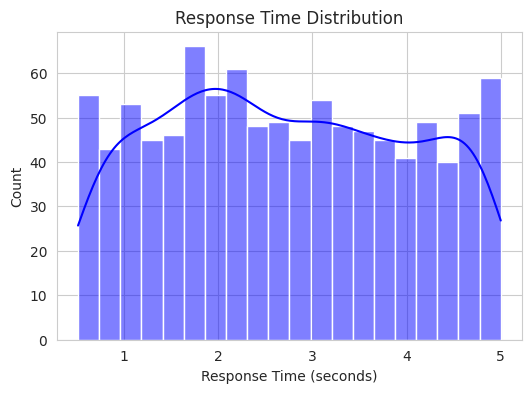

In [ ]:
#How fast is the chatbot responding
plt.figure(figsize=(6,4))
sns.histplot(df["Response Time (seconds)"], bins=20, kde=True, color="blue")
plt.title("Response Time Distribution")
plt.xlabel("Response Time (seconds)")
plt.ylabel("Count")
plt.show()

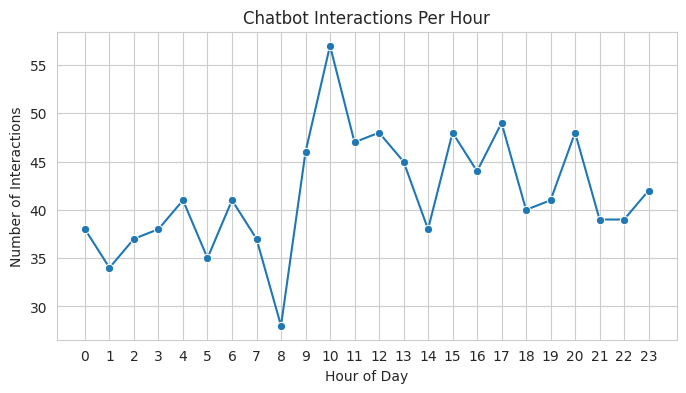

In [ ]:
#Analyze interactions per hour to identify peak usage times
plt.figure(figsize=(8,4))
sns.lineplot(x=df["Hour"].value_counts().index, y=df["Hour"].value_counts().values, marker="o")
plt.title("Chatbot Interactions Per Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Interactions")
plt.xticks(range(24))
plt.show()

In [ ]:
!pip install nltk spacy
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 60.9 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import nltk
import spacy
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download("punkt")
nltk.download("stopwords")
nltk.download("wordnet")

# Load spaCy model
nlp = spacy.load("en_core_web_sm")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [ ]:
import nltk
import spacy
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Download necessary NLTK data
nltk.download("punkt")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download('punkt_tab') # Download the punkt_tab data

# Load spaCy model
nlp = spacy.load("en_core_web_sm")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [ ]:
# Initialize stopwords and tokenizer
stop_words = set(stopwords.words("english"))

def preprocess_text(text):
    tokens = word_tokenize(text.lower())  # Tokenization & lowercasing
    tokens = [word for word in tokens if word.isalpha()]  # Remove punctuation
    tokens = [word for word in tokens if word not in stop_words]  # Remove stopwords
    return tokens

# Apply preprocessing to user queries
df["Processed Query"] = df["User Query"].apply(preprocess_text)
df.head()


,Timestamp,User Query,Chatbot Response,Sentiment,Response Time (seconds),Intent,Hour,Day,Month,Processed Query
0,2025-03-04 08:29:00,how do i reset my password?,i am a virtual assistant.,Positive,2.09,Refunds,8,4,3,"[reset, password]"
1,2025-03-03 10:55:00,i want to cancel my order.,why don’t scientists trust atoms? because they...,Positive,2.39,Order Management,10,3,3,"[want, cancel, order]"
2,2025-03-02 02:55:00,who are you?,you can reset your password by clicking on 'fo...,Neutral,3.06,Gratitude,2,2,3,[]
3,2025-03-04 17:14:00,who are you?,refunds typically take 5-7 business days.,Negative,3.02,Gratitude,17,4,3,[]
4,2025-03-02 16:53:00,how do i reset my password?,i can help with that. what is your order id?,Neutral,3.88,Introduction,16,2,3,"[reset, password]"


In [ ]:
lemmatizer = WordNetLemmatizer()

def lemmatize_text(tokens):
    return [lemmatizer.lemmatize(word) for word in tokens]

# Apply lemmatization
df["Lemmatized Query"] = df["Processed Query"].apply(lemmatize_text)
df.head()


,Timestamp,User Query,Chatbot Response,Sentiment,Response Time (seconds),Intent,Hour,Day,Month,Processed Query,Lemmatized Query
0,2025-03-04 08:29:00,how do i reset my password?,i am a virtual assistant.,Positive,2.09,Refunds,8,4,3,"[reset, password]","[reset, password]"
1,2025-03-03 10:55:00,i want to cancel my order.,why don’t scientists trust atoms? because they...,Positive,2.39,Order Management,10,3,3,"[want, cancel, order]","[want, cancel, order]"
2,2025-03-02 02:55:00,who are you?,you can reset your password by clicking on 'fo...,Neutral,3.06,Gratitude,2,2,3,[],[]
3,2025-03-04 17:14:00,who are you?,refunds typically take 5-7 business days.,Negative,3.02,Gratitude,17,4,3,[],[]
4,2025-03-02 16:53:00,how do i reset my password?,i can help with that. what is your order id?,Neutral,3.88,Introduction,16,2,3,"[reset, password]","[reset, password]"


In [ ]:
from nltk.sentiment import SentimentIntensityAnalyzer

nltk.download("vader_lexicon")
sia = SentimentIntensityAnalyzer()

def get_sentiment(text):
    score = sia.polarity_scores(" ".join(text))  # Convert token list to string
    if score["compound"] >= 0.05:
        return "Positive"
    elif score["compound"] <= -0.05:
        return "Negative"
    else:
        return "Neutral"

# Apply sentiment analysis
df["Predicted Sentiment"] = df["Lemmatized Query"].apply(get_sentiment)

# Compare predicted vs actual sentiment
df[["User Query", "Sentiment", "Predicted Sentiment"]].head()


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


,User Query,Sentiment,Predicted Sentiment
0,how do i reset my password?,Positive,Neutral
1,i want to cancel my order.,Positive,Negative
2,who are you?,Neutral,Neutral
3,who are you?,Negative,Neutral
4,how do i reset my password?,Neutral,Neutral


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# Convert text data into a bag-of-words model
vectorizer = CountVectorizer(max_features=1000, stop_words="english")
X = vectorizer.fit_transform(df["User Query"])

# Apply LDA for topic extraction
lda = LatentDirichletAllocation(n_components=3, random_state=42)  # Extract 3 topics
lda.fit(X)

# Print top words for each topic
words = vectorizer.get_feature_names_out()
for i, topic in enumerate(lda.components_):
    print(f"Topic {i+1}: ", [words[j] for j in topic.argsort()[-10:]])

Topic 1:  ['password', 'reset', 'thank', 'refund', 'hello', 'help', 'book', 'appointment', 'tell', 'joke']
Topic 2:  ['reset', 'thank', 'refund', 'hello', 'want', 'order', 'cancel', 'like', 'today', 'weather']
Topic 3:  ['want', 'joke', 'tell', 'password', 'reset', 'hours', 'working', 'hello', 'refund', 'thank']


In [ ]:
!pip install scikit-learn

In [ ]:
import pandas as pd
import numpy as np
import re
import nltk
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

nltk.download("punkt")


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [ ]:
# Load dataset
df = pd.read_csv("/content/chatbot_interactions.csv")

# Text preprocessing function
def preprocess_text(text):
    text = text.lower()  # Convert to lowercase
    text = re.sub(r'\W', ' ', text)  # Remove special characters
    tokens = word_tokenize(text)  # Tokenization
    return " ".join(tokens)

# Apply preprocessing to user queries
df["Cleaned Query"] = df["User Query"].apply(preprocess_text)

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(df["Cleaned Query"], df["Intent"], test_size=0.2, random_state=42)

# Convert text data into numerical format using TF-IDF
vectorizer = TfidfVectorizer(max_features=1000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)


In [ ]:
# Train Random Forest Classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train_tfidf, y_train)

# Predict on test data
y_pred = clf.predict(X_test_tfidf)


In [ ]:
def predict_intent(query):
    query = preprocess_text(query)
    query_tfidf = vectorizer.transform([query])
    intent = clf.predict(query_tfidf)[0]
    return intent

# Example test
user_input = "Who are you?"
predicted_intent = predict_intent(user_input)
print(f"Predicted Intent: {predicted_intent}")


Predicted Intent: Account Support


In [ ]:
import numpy as np
import pandas as pd
import re
import nltk
import tensorflow as tf
from nltk.tokenize import word_tokenize
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

nltk.download("punkt")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [ ]:
# Load dataset
df = pd.read_csv("/content/chatbot_interactions.csv")

# Text preprocessing function
def preprocess_text(text):
    text = text.lower()  # Convert to lowercase
    text = re.sub(r'\W', ' ', text)  # Remove special characters
    tokens = word_tokenize(text)  # Tokenization
    return " ".join(tokens)

# Apply preprocessing
df["Cleaned Query"] = df["User Query"].apply(preprocess_text)

# Encode intent labels
label_encoder = LabelEncoder()
df["Encoded Intent"] = label_encoder.fit_transform(df["Intent"])

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(df["Cleaned Query"], df["Encoded Intent"], test_size=0.2, random_state=42)


In [ ]:
# Tokenization
tokenizer = Tokenizer(num_words=5000, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Padding sequences
max_length = max(len(seq) for seq in X_train_seq)
X_train_pad = pad_sequences(X_train_seq, maxlen=max_length, padding="post")
X_test_pad = pad_sequences(X_test_seq, maxlen=max_length, padding="post")


In [ ]:
# Define LSTM model
model = Sequential([
    Embedding(input_dim=5000, output_dim=64, input_length=max_length),
    LSTM(64, return_sequences=True),
    LSTM(32),
    Dropout(0.5),
    Dense(32, activation="relu"),
    Dense(len(df["Intent"].unique()), activation="softmax")
])

# Compile the model
model.compile(loss="sparse_categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

# Model summary
model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Evaluate on test data
test_loss, test_acc = model.evaluate(X_test_pad, y_test)
print(f"Test Accuracy: {test_acc:.2f}")


7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.1162 - loss: 2.3025
Test Accuracy: 0.09


In [ ]:
# Test with a New Query
def predict_intent_lstm(query):
    query = preprocess_text(query)
    query_seq = tokenizer.texts_to_sequences([query])
    query_pad = pad_sequences(query_seq, maxlen=max_length, padding="post")
    prediction = np.argmax(model.predict(query_pad), axis=-1)
    intent = label_encoder.inverse_transform(prediction)[0]
    return intent

# Example test
user_input = "How do I reset my password?"
predicted_intent = predict_intent_lstm(user_input)
print(f"Predicted Intent: {predicted_intent}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
Predicted Intent: Weather


In [ ]:
#